# Регрессия: прогнозирование стоимости недвижимости
## Санкт-Петербург и область

**Цель работы:** научиться решать задачу регрессии на примере прогнозирования цены квартиры.

**Этапы:**
1. Загрузка и фильтрация данных
2. Очистка (пропуски, выбросы)
3. Создание новых признаков
4. Кодирование категорий
5. Обучение моделей (Ridge, XGBoost)
6. Оценка и сравнение
7. Скоринг нового объекта

---

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import category_encoders as ce
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [14]:
df = pd.read_csv('all_v2.csv', sep=',')

## 1. Проверка на пропуски

Проверяем наличие и количество пропусков в данных

In [18]:
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_table = pd.DataFrame({'Пропуски': null_counts, 'Доля %': null_percent})
null_table[null_table['Пропуски'] > 0].sort_values('Пропуски', ascending=False)

,Пропуски,Доля %


## 2. Проверка данных на наличие выбросов

Проверяем наличие и количество выбросов в данных

In [19]:
df.describe()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06
mean,4.422029e+06,5.403826e+01,5.324433e+01,4.307141e+03,1.948966e+00,6.214530e+00,1.139892e+01,1.726173e+00,5.391825e+01,1.062840e+01,3.945399e+00
std,2.150752e+07,4.622758e+00,2.074763e+01,3.308050e+03,1.038537e+00,4.957419e+00,6.535734e+00,1.082133e+00,3.335293e+01,9.792380e+00,4.558357e+00
min,-2.144967e+09,4.145906e+01,1.989020e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.000000e+00,7.000000e-02,1.000000e-02,1.000000e+00
25%,1.950000e+06,5.337768e+01,3.777790e+01,2.661000e+03,1.000000e+00,2.000000e+00,5.000000e+00,1.000000e+00,3.800000e+01,7.000000e+00,1.000000e+00
50%,2.990000e+06,5.517139e+01,4.306774e+01,2.922000e+03,2.000000e+00,5.000000e+00,1.000000e+01,2.000000e+00,4.802000e+01,9.700000e+00,1.000000e+00
75%,4.802000e+06,5.622613e+01,6.564895e+01,6.171000e+03,3.000000e+00,9.000000e+00,1.600000e+01,2.000000e+00,6.313000e+01,1.270000e+01,1.100000e+01
max,2.147484e+09,7.198040e+01,1.625361e+02,6.188800e+04,5.000000e+00,3.900000e+01,3.900000e+01,1.000000e+01,7.856000e+03,9.999000e+03,1.100000e+01


In [20]:
print(f"Цена - пропуски: {df['price'].isnull().sum()}")
print(f"Цена - min: {df['price'].min()}")
print(f"Цена - max: {df['price'].max()}")
print(f"Цена - mean: {df['price'].mean():.2f}")

Цена - пропуски: 0
Цена - min: -2144967296
Цена - max: 2147483647
Цена - mean: 4422029.02


Убираем отрицательные цены

In [21]:
df = df[df['price'] > 0]

## 3. Фильтрация по региону

Оставляем только регион 2661 (Санкт-Петербург и область).

In [22]:
df = df[df['region'] == 2661].copy()
print(f"После фильтрации по региону 2661: {df.shape}")

После фильтрации по региону 2661: (461796, 13)


In [23]:
print(f"Цена - min: {df['price'].min()}")
print(f"Цена - max: {df['price'].max()}")
print(f"Цена - mean: {df['price'].mean():.2f}")
print(f"Цена - отрицательные: {(df['price'] < 0).sum()}")
print(f"Цена - нулевые: {(df['price'] == 0).sum()}")
print(f"\narea - min: {df['area'].min()}")
print(f"area - max: {df['area'].max()}")
print(f"kitchen_area - min: {df['kitchen_area'].min()}")
print(f"kitchen_area - max: {df['kitchen_area'].max()}")
print(f"rooms - уникальные значения: {df['rooms'].unique()}")

Цена - min: 1
Цена - max: 1945382704
Цена - mean: 8251657.69
Цена - отрицательные: 0
Цена - нулевые: 0

area - min: 1.4
area - max: 7856.0
kitchen_area - min: 0.02
kitchen_area - max: 1272.0
rooms - уникальные значения: [ 3  1  2 -1  4  6  5  7  8  9 -2]


Комнаты не могут быть орицательными!!! Заменим их на их на 0, как и сказанно в задании

## 4. Фильтрация по площади и цене

In [24]:
df = df[(df['area'] >= 20) & (df['area'] <= 200)]
print(f"После фильтрации по area (20-200): {df.shape}")

После фильтрации по area (20-200): (456448, 13)


In [25]:
df = df[(df['kitchen_area'] >= 6) & (df['kitchen_area'] <= 30)]
print(f"После фильтрации по kitchen_area (6-30): {df.shape}")

После фильтрации по kitchen_area (6-30): (412451, 13)


In [26]:
df = df[(df['price'] >= 1500000) & (df['price'] <= 50000000)]
print(f"После фильтрации по price (1.5-50 млн): {df.shape}")

После фильтрации по price (1.5-50 млн): (410663, 13)


In [28]:
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates}")

# Если есть дубликаты — удаляем
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"После удаления дубликатов: {df.shape}")

Количество полных дубликатов строк: 0


In [29]:
print("=== ИТОГОВАЯ СТАТИСТИКА ПОСЛЕ ОЧИСТКИ ===")
print(f"\nКоличество записей: {len(df)}")
print(f"\nprice:")
print(f"  min: {df['price'].min():,.0f}")
print(f"  max: {df['price'].max():,.0f}")
print(f"  mean: {df['price'].mean():,.0f}")
print(f"\narea:")
print(f"  min: {df['area'].min()}")
print(f"  max: {df['area'].max()}")
print(f"  mean: {df['area'].mean():.1f}")
print(f"\nkitchen_area:")
print(f"  min: {df['kitchen_area'].min()}")
print(f"  max: {df['kitchen_area'].max()}")
print(f"  mean: {df['kitchen_area'].mean():.1f}")
print(f"\nrooms:")
print(f"  уникальные значения: {sorted(df['rooms'].unique())}")

=== ИТОГОВАЯ СТАТИСТИКА ПОСЛЕ ОЧИСТКИ ===

Количество записей: 410481

price:
  min: 1,500,000
  max: 50,000,000
  mean: 7,596,029

area:
  min: 20.0
  max: 200.0
  mean: 57.5

kitchen_area:
  min: 6.0
  max: 30.0
  mean: 12.6

rooms:
  уникальные значения: [np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 5. Убираем отрицательные значения комнат

In [30]:
df['rooms'] = df['rooms'].replace([-1, -2], 0)
print(f"rooms после замены: {sorted(df['rooms'].unique())}")

rooms после замены: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


Проверка

In [31]:
print(f"\nРаспределение rooms:")
print(df['rooms'].value_counts().sort_index())


Распределение rooms:
rooms
0      5027
1    165397
2    140172
3     84012
4     12711
5      2545
6       426
7       124
8        42
9        25
Name: count, dtype: int64


## 6. Добавление новых признаков

- `floor_ratio` = этаж / этажность
- `first_floor`, `last_floor`
- `ratio` = кухня / общая (если комнат 0, то `ratio = area`)
- `days_since` = давность объявления в днях от максимальной даты в данных

In [32]:
# Признак 1: отношение этажа к этажности (с защитой от деления на 0)
df['floor_ratio'] = df.apply(
    lambda row: row['level'] / row['levels'] if row['levels'] > 0 else 0, 
    axis=1
)

# Признак 2: первый этаж
df['first_floor'] = (df['level'] == 1).astype(int)

# Признак 3: последний этаж
df['last_floor'] = (df['level'] == df['levels']).astype(int)

# Признак 4: ratio (kitchen_area / area) с правилом для rooms == 0
df['ratio'] = df.apply(
    lambda row: row['area'] if row['rooms'] == 0 else row['kitchen_area'] / row['area'],
    axis=1
)

In [33]:
print("Новые признаки:")
print(f"floor_ratio - min: {df['floor_ratio'].min():.2f}, max: {df['floor_ratio'].max():.2f}")
print(f"first_floor - доля 1: {df['first_floor'].mean():.3f}")
print(f"last_floor - доля 1: {df['last_floor'].mean():.3f}")
print(f"ratio - min: {df['ratio'].min():.2f}, max: {df['ratio'].max():.2f}")

# Проверка правила для rooms == 0
print(f"\nПроверка для rooms == 0 (первые 5):")
print(df[df['rooms'] == 0][['area', 'kitchen_area', 'rooms', 'ratio']].head())

Новые признаки:
floor_ratio - min: 0.03, max: 4.00
first_floor - доля 1: 0.064
last_floor - доля 1: 0.086
ratio - min: 0.03, max: 195.80

Проверка для rooms == 0 (первые 5):
      area  kitchen_area  rooms  ratio
2189  29.0           6.0      0   29.0
4952  29.0           6.0      0   29.0
8006  28.0           6.0      0   28.0
8077  25.7          17.6      0   25.7
8269  31.0           6.0      0   31.0


## **Этаж не может быть больше этажности здания, поэтому такие строки необходимо удалить**

In [34]:
# Находим строки где level > levels
bad_floor = df[df['level'] > df['levels']]
print(f"Количество записей с level > levels: {len(bad_floor)}")
print(f"\nПримеры:")
print(bad_floor[['level', 'levels', 'floor_ratio']].head(10))

Количество записей с level > levels: 42

Примеры:
        level  levels  floor_ratio
758284     23      10     2.300000
763060     23      10     2.300000
764078     12       8     1.500000
764112     23      10     2.300000
764848     12       8     1.500000
764878     16       9     1.777778
764953     12       8     1.500000
767450     12       8     1.500000
768003     12       8     1.500000
768808     16       9     1.777778


In [67]:
# Удаляем аномалии (level > levels)
df = df[df['level'] <= df['levels']].copy()
print(f"После удаления аномалий этажей: {df.shape}")

После удаления аномалий этажей: (410439, 13)


## Диагностика выбросов в признаке `ratio`

**Что такое `ratio`?**
- По заданию: `ratio = kitchen_area / area` (доля площади кухни в общей площади)
- **Особое правило:** если `rooms == 0`, то `ratio = area` (вся площадь квартиры)

**Почему это может давать большие значения?**
- При `rooms == 0` и `area = 100 кв.м.` → `ratio = 100`
- В обычных квартирах `ratio` редко превышает 0.5 (кухня 10 кв.м. / общая 55 кв.м.)

**Что мы проверяем?**
- Ищем записи с `ratio > 30` — это потенциальные выбросы

**Результаты диагностики:**
- Найдено 1 546 записей с `ratio > 30`
- Все они имеют `rooms == 0` (студии или объекты без выделенных комнат)
- Максимальное значение `ratio = 195.8` (соответствует `area = 195.8`)

**Принятое решение:**
**Оставить как есть**

**Обоснование:**
1. Это не ошибка данных, а особенность формулы из задания
2. Таких записей всего 0.38% от общего объёма
3. Удаление может исказить представление модели о квартирах-студиях
4. XGBoost устойчив к выбросам и сам определит важность признака

In [35]:
# Находим строки с ratio > 30 (явный выброс)
bad_ratio = df[df['ratio'] > 30]
print(f"Количество записей с ratio > 30: {len(bad_ratio)}")
print(f"\nПримеры:")
print(bad_ratio[['area', 'kitchen_area', 'rooms', 'ratio']].head(10))
print(f"\nСтатистика ratio > 30:")
print(bad_ratio['ratio'].describe())

Количество записей с ratio > 30: 1546

Примеры:
       area  kitchen_area  rooms  ratio
8269   31.0           6.0      0   31.0
9402   55.0          10.0      0   55.0
20192  32.0          10.0      0   32.0
31290  39.0          10.0      0   39.0
43513  57.0          12.0      0   57.0
47701  42.0          10.0      0   42.0
63766  42.0           7.0      0   42.0
63987  31.6           6.0      0   31.6
65747  31.5           6.0      0   31.5
97235  32.0           7.0      0   32.0

Статистика ratio > 30:
count    1546.000000
mean       43.178448
std        23.563101
min        30.100000
25%        32.000000
50%        35.000000
75%        42.400000
max       195.800000
Name: ratio, dtype: float64


In [37]:
df['date'] = pd.to_datetime(df['date'])
print(f"date - min: {df['date'].min()}")
print(f"date - max: {df['date'].max()}")

date - min: 2018-02-19 00:00:00
date - max: 2021-05-01 00:00:00


## Добавление признака "Давность объявления"

**Было принято решение использовать максимальную дату в датасете как точку отсчёта**
- Новый объект при добавлении будет иметь давность 0

In [38]:
# Преобразуем date в datetime, если ещё не сделали
df['date'] = pd.to_datetime(df['date'])

# Максимальная дата в данных
max_date = df['date'].max()
print(f"Точка отсчёта: {max_date}")

# Добавляем признак давности (в днях)
df['days_since'] = (max_date - df['date']).dt.days

# Проверка
print(f"\nПризнак days_since:")
print(f"  min: {df['days_since'].min()} дней")
print(f"  max: {df['days_since'].max()} дней")
print(f"  mean: {df['days_since'].mean():.1f} дней")

# Проверка распределения
print(f"\nРаспределение (квантили):")
print(df['days_since'].quantile([0, 0.25, 0.5, 0.75, 1]))

Точка отсчёта: 2021-05-01 00:00:00

Признак days_since:
  min: 0 дней
  max: 1167 дней
  mean: 470.7 дней

Распределение (квантили):
0.00       0.0
0.25     252.0
0.50     441.0
0.75     698.0
1.00    1167.0
Name: days_since, dtype: float64


## Матрица корреляции признаков

- Необходимо найти признаки с мультиколлинеарностью (кореляция > 0,8), их наличие может помешать качественному обучению линейной модели

=== Корреляция с price ===
price           1.000000
area            0.780296
rooms           0.524617
kitchen_area    0.490285
floor_ratio     0.074407
last_floor      0.037854
ratio          -0.051619
first_floor    -0.060721
level          -0.076612
days_since     -0.146820
levels         -0.177542
Name: price, dtype: float64


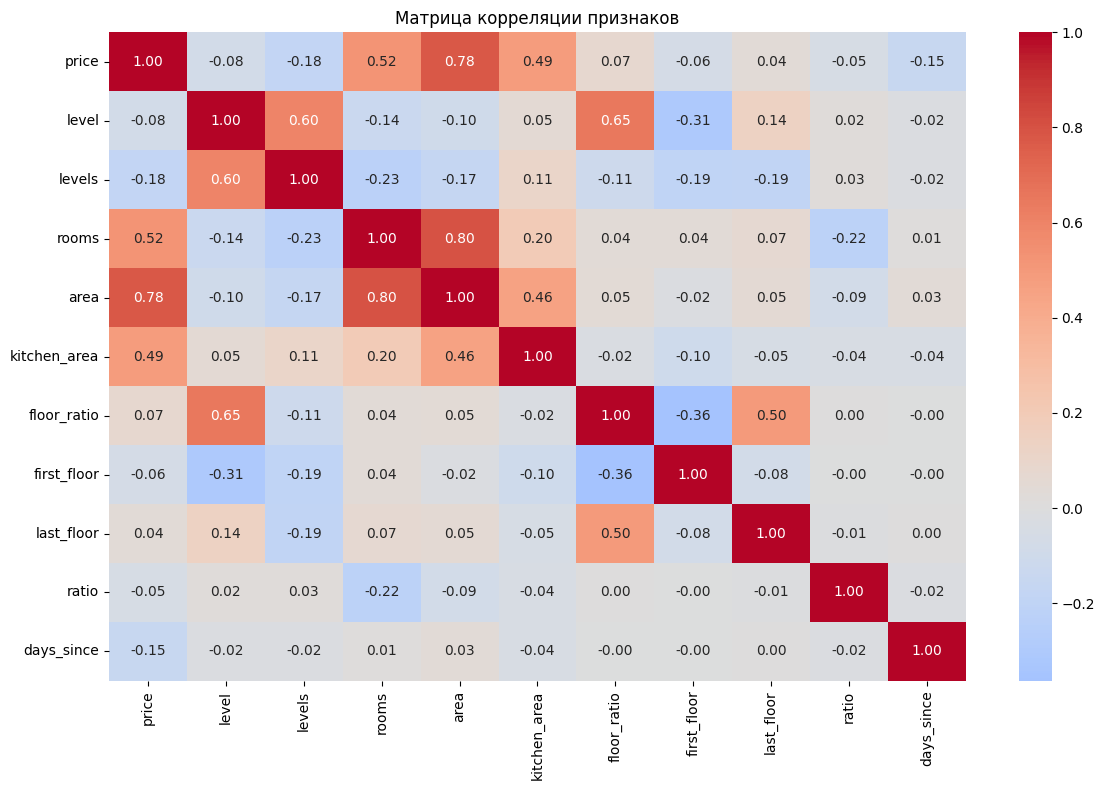

In [70]:
# Выбираем числовые признаки для корреляции
numeric_cols = ['price', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 
                'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']

corr_matrix = df[numeric_cols].corr()

# Корреляция с целевой переменной price
print("=== Корреляция с price ===")
print(corr_matrix['price'].sort_values(ascending=False))

# Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

In [40]:
# Удаляем region (стал константой) и временные признаки (date, time)
df = df.drop(columns=['region', 'date', 'time', 'geo_lat', 'geo_lon'], errors='ignore')
print(f"Колонки после удаления: {df.columns.tolist()}")

Колонки после удаления: ['price', 'building_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type', 'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']


## Binary-кодирование категориальных признаков

Binary Encoder преобразует категориальные признаки в **бинарные (0/1)** столбцы, представляя каждую категорию в виде двоичного кода.

### Почему Binary, а не One-Hot?

Данный метод кодирования добавляет меньше признаков и поэтому размерность данных меньше в отличие от One-Hot кодирования, это предотвращает переобучение модели, ведь чем больше признаков, тем легче модели запомнить шум, вместо того чтобы обобщать признаки.

### Результаты кодирования

| Показатель | Значение |
|------------|----------|
| Размер до кодирования | (410 481, 13) |
| Размер после кодирования | (410 481, 15) |
| Новых признаков добавлено | +2 (вместо +4–6 при One-Hot) |


In [41]:
print("building_type - уникальные значения:", df['building_type'].unique())
print("object_type - уникальные значения:", df['object_type'].unique())
print(f"\nТипы:\nbuilding_type: {df['building_type'].dtype}")
print(f"object_type: {df['object_type'].dtype}")

building_type - уникальные значения: [1 3 2 4 0 5]
object_type - уникальные значения: [ 1 11]

Типы:
building_type: int64
object_type: int64


In [42]:
# Выбираем категориальные признаки
cat_features = ['building_type', 'object_type']

# Binary Encoder
binary_encoder = ce.BinaryEncoder(cols=cat_features)
df_encoded = binary_encoder.fit_transform(df)

print(f"Размер после кодирования: {df_encoded.shape}")
print(f"\nНовые колонки от building_type:")
print([col for col in df_encoded.columns if 'building_type' in col])
print(f"\nНовые колонки от object_type:")
print([col for col in df_encoded.columns if 'object_type' in col])

Размер после кодирования: (410481, 16)

Новые колонки от building_type:
['building_type_0', 'building_type_1', 'building_type_2']

Новые колонки от object_type:
['object_type_0', 'object_type_1']


**Разделение данных со стратификацией**

In [44]:
# Целевая переменная
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nЦелевая переменная - train mean: {y_train.mean():,.0f}")
print(f"Целевая переменная - test mean: {y_test.mean():,.0f}")

Размер обучающей выборки: (328384, 15)
Размер тестовой выборки: (82097, 15)

Целевая переменная - train mean: 7,605,438
Целевая переменная - test mean: 7,558,391


## Стандартизация числовых признаков

In [72]:
# Определяем числовые признаки для масштабирования (не бинарные)
numeric_features = ['level', 'levels', 'rooms', 'area', 'kitchen_area', 
                    'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']

# Бинарные признаки (не масштабируем)
binary_features = [col for col in X_train.columns if 'building_type_' in col or 'object_type_' in col]

print(f"Масштабируемые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Бинарные признаки ({len(binary_features)}): {binary_features}")

# Масштабирование
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("\nМасштабирование выполнено")
print(f"Train mean area после масштабирования: {X_train_scaled['area'].mean():.10f}")
print(f"Train std area после масштабирования: {X_train_scaled['area'].std():.2f}")

Масштабируемые признаки (10): ['level', 'levels', 'rooms', 'area', 'kitchen_area', 'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']
Бинарные признаки (5): ['building_type_0', 'building_type_1', 'building_type_2', 'object_type_0', 'object_type_1']

Масштабирование выполнено
Train mean area после масштабирования: 0.0000000000
Train std area после масштабирования: 1.00


## Обучение модели Ridge (L2-регуляризация)

In [75]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def rmsle(y_true, y_pred):
    # Обрезаем предсказания до минимального значения в y_true
    y_pred_clipped = np.maximum(y_pred, y_true.min())
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

# Обучаем Ridge с positive=True
ridge = Ridge(alpha=1.0, positive=True, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Предсказания (уже положительные)
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

print(f"min y_train_pred_ridge: {y_train_pred_ridge.min():.0f}")
print(f"max y_train_pred_ridge: {y_train_pred_ridge.max():.0f}")

# Метрики
print("\n=== RIDGE REGRESSION (positive=True) ===")
print(f"\nОбучающая выборка:")
print(f"  RMSLE: {rmsle(y_train, y_train_pred_ridge):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_train_pred_ridge):,.0f}")
print(f"  R2: {r2_score(y_train, y_train_pred_ridge):.4f}")

print(f"\nТестовая выборка:")
print(f"  RMSLE: {rmsle(y_test, y_test_pred_ridge):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_test_pred_ridge):,.0f}")
print(f"  R2: {r2_score(y_test, y_test_pred_ridge):.4f}")

print(f"\nРазница R2 (train - test): {r2_score(y_train, y_train_pred_ridge) - r2_score(y_test, y_test_pred_ridge):.4f}")

min y_train_pred_ridge: 104480
max y_train_pred_ridge: 31426667

=== RIDGE REGRESSION (positive=True) ===

Обучающая выборка:
  RMSLE: 0.3130
  MAE: 1,878,807
  R2: 0.6379

Тестовая выборка:
  RMSLE: 0.3122
  MAE: 1,867,682
  R2: 0.6379

Разница R2 (train - test): -0.0000


## Что показала модель Ridge

### Цифры

| Показатель | Значение |
|------------|----------|
| Минимальное предсказание | 104 480 руб. |
| Максимальное предсказание | 31.4 млн руб. |
| Ошибка (MAE) | ~1.87 млн руб. |
| Качество (R2) | 0.64 |

**Ошибка ~1.87 млн рублей** — модель ошибается в среднем на 1.87 млн. Для квартиры за 5 млн это много (37% погрешность).

**R2 = 0.64** — модель объясняет 64% того, от чего зависит цена. Остальные 36% — это то, что модель не учла

- Модель **не переобучилась** (на обучающих и тестовых данных результаты одинаковые)

## Обучение модели XGBOOST REGRESSION

In [74]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def rmsle(y_true, y_pred):
    y_pred_clipped = np.maximum(y_pred, y_true.min())
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

# XGBoost на исходных данных (без масштабирования)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Предсказания
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

print("=== XGBOOST REGRESSION ===")
print(f"\nОбучающая выборка:")
print(f"  RMSLE: {rmsle(y_train, y_train_pred_xgb):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_train_pred_xgb):,.0f}")
print(f"  R2: {r2_score(y_train, y_train_pred_xgb):.4f}")

print(f"\nТестовая выборка:")
print(f"  RMSLE: {rmsle(y_test, y_test_pred_xgb):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_test_pred_xgb):,.0f}")
print(f"  R2: {r2_score(y_test, y_test_pred_xgb):.4f}")

print(f"\nРазница R2 (train - test): {r2_score(y_train, y_train_pred_xgb) - r2_score(y_test, y_test_pred_xgb):.4f}")

=== XGBOOST REGRESSION ===

Обучающая выборка:
  RMSLE: 0.2238
  MAE: 1,277,061
  R2: 0.8153

Тестовая выборка:
  RMSLE: 0.2251
  MAE: 1,283,650
  R2: 0.8073

Разница R2 (train - test): 0.0080


## Что показала модель XGBOOST REGRESSION

| Показатель | Обучающая выборка | Тестовая выборка |
|------------|-------------------|------------------|
| RMSLE | 0.2238 | 0.2251 |
| MAE | 1 277 061 руб. | 1 283 650 руб. |
| R2 | 0.8153 | 0.8073 |

**Ошибка (MAE) ≈ 1.28 млн рублей**
- Модель ошибается в среднем на 1.28 млн
- Для квартиры за 5 млн это погрешность ~26%

**R2 = 0.81 на тесте**
- Модель объясняет 81% того, от чего зависит цена
- Остальные 19% — то, что не учли (район, ремонт, сезон)

### Сравнение с Ridge

| Показатель | Ridge | XGBoost | Улучшение |
|------------|-------|---------|------------|
| MAE | 1.87 млн | 1.28 млн | **на 590 тыс. руб.** ↓ |
| R2 | 0.64 | 0.81 | **на 27%** ↑ |


============================================================
ВЫВОДЫ:
============================================================
✅ XGBoost лучше Ridge по всем метрикам:
   - RMSLE лучше на 27.9%
   - MAE лучше на 31.3%
   - R2 лучше на 26.6%

=== ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost) ===
        feature  importance
           area    0.661626
     days_since    0.057497
         levels    0.057145
building_type_2    0.046342
          rooms    0.035601
   kitchen_area    0.031768
building_type_1    0.029839
building_type_0    0.025173
  object_type_0    0.016521
    floor_ratio    0.016130
          level    0.014202
          ratio    0.008156
  object_type_1    0.000000
     last_floor    0.000000
    first_floor    0.000000


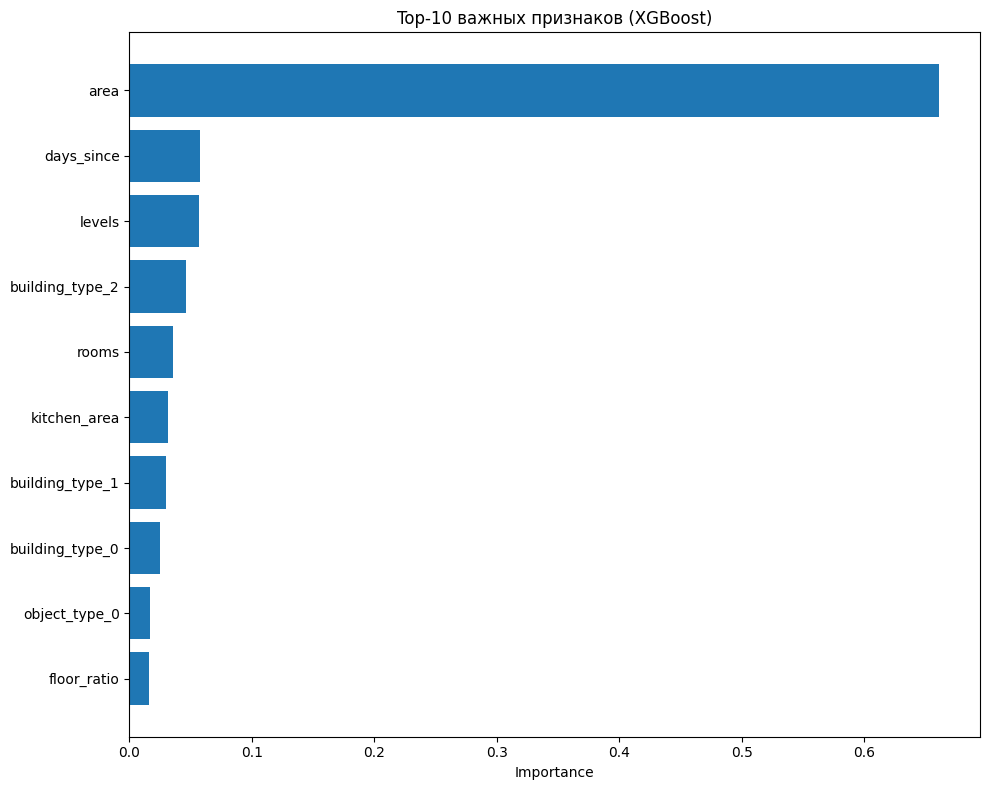

In [55]:
import matplotlib.pyplot as plt

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost) ===")
print(feature_importance.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top-10 важных признаков (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Прогнозирование было оформленно в виде функции которой передаются все необходимые признаки

In [ ]:
def predict_flat_price(level, levels, rooms, area, kitchen_area, building_type, object_type, 
                        date='2026-04-19', time='00:00:00', geo_lat=59.93, geo_lon=30.31, 
                        region=2661, days_since=0):
    """
    Функция предсказания цены квартиры на основе обученной модели XGBoost.
    
    Параметры:
    ----------
    level : int - этаж квартиры
    levels : int - этажность дома
    rooms : int - количество комнат (0,1,2,...)
    area : float - общая площадь (кв.м.)
    kitchen_area : float - площадь кухни (кв.м.)
    building_type : int - тип здания (1-5)
    object_type : int - тип объекта (1-11)
    date : str - дата объявления (по умолчанию сегодня)
    time : str - время объявления
    geo_lat : float - широта
    geo_lon : float - долгота
    region : int - регион (по умолчанию 2661 - СПб)
    days_since : int - давность объявления в днях (по умолчанию 0)
    
    Возвращает:
    -----------
    price : float - предсказанная цена в рублях
    """
    
    # 1. Создаём DataFrame с исходными признаками
    new_object_base = pd.DataFrame({
        'price': [0],
        'date': [date],
        'time': [time],
        'geo_lat': [geo_lat],
        'geo_lon': [geo_lon],
        'region': [region],
        'building_type': [building_type],
        'level': [level],
        'levels': [levels],
        'rooms': [rooms],
        'area': [area],
        'kitchen_area': [kitchen_area],
        'object_type': [object_type]
    })
    
    # 2. Применяем BinaryEncoder (глобальный объект binary_encoder)
    new_object_encoded = binary_encoder.transform(new_object_base)
    
    # 3. Добавляем расчётные признаки
    new_object_encoded['floor_ratio'] = new_object_encoded['level'] / new_object_encoded['levels']
    new_object_encoded['first_floor'] = (new_object_encoded['level'] == 1).astype(int)
    new_object_encoded['last_floor'] = (new_object_encoded['level'] == new_object_encoded['levels']).astype(int)
    new_object_encoded['ratio'] = new_object_encoded.apply(
        lambda row: row['area'] if row['rooms'] == 0 else row['kitchen_area'] / row['area'],
        axis=1
    )
    new_object_encoded['days_since'] = days_since
    
    # 4. Оставляем только нужные колонки (как при обучении)
    columns_to_keep = ['building_type_0', 'building_type_1', 'building_type_2', 
                       'level', 'levels', 'rooms', 'area', 'kitchen_area', 
                       'object_type_0', 'object_type_1', 'floor_ratio', 
                       'first_floor', 'last_floor', 'ratio', 'days_since']
    
    new_object_clean = new_object_encoded[columns_to_keep]
    
    # 5. Масштабируем числовые признаки
    numeric_features = ['level', 'levels', 'rooms', 'area', 'kitchen_area', 
                        'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']
    numeric_features_existing = [f for f in numeric_features if f in new_object_clean.columns]
    
    new_object_scaled = new_object_clean.copy()
    new_object_scaled[numeric_features_existing] = scaler.transform(new_object_clean[numeric_features_existing])
    
    # 6. Предсказание
    prediction = xgb_model.predict(new_object_scaled)[0]
    
    return prediction


In [80]:
print("="*60)

# Пример 1: наша тестовая квартира
price1 = predict_flat_price(
    level=6, levels=12, rooms=2, 
    area=52.2, kitchen_area=8.1, 
    building_type=2, object_type=1
)
print(f"   Цена: {price1:,.0f} руб. ({price1/1_000_000:.2f} млн руб.)")

print("="*60)

   Цена: 4,514,579 руб. (4.51 млн руб.)


## Валидация модели на реальном примере

Для примера была взята квартира за 10 500 000 ₽ ([ссылка на объявление](https://spb.cian.ru/sale/flat/328959332/))

**Прогнозная цена модели — 4.51 млн руб.**

Этот результат на мой взгляд вполне может быть валидным, с учетом того что:
- модель ошибается в среднем на 1.28 миллиона
- по найденным мною данным с июня 2019 года по июнь 2024 года средняя цена квадратного метра на вторичном рынке недвижимости в Санкт-Петербурге выросла на 75,9% (или на 90,9 тыс. рублей) ([источник](https://stroygaz.ru/news/dwelling/vtorichka-peterburga-za-pyat-let-podorozhala-pochti-na-80/))

Из этого можно сделать вывод, что стоимость квартиры так же увеличилась примерно в 2 раза, что в целом соответсвует предсказанной цене.